In [1]:
#Surpress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load dataset into a pandas dataframe "df"
df = pd.read_csv('FastFoodNutritionMenuV2.csv')

#Print the first five rows
df

,Company,Item,Calories,Calories from\nFat,Total Fat\n(g),Saturated Fat\n(g),Trans Fat\n(g),Cholesterol\n(mg),Sodium \n(mg),Carbs\n(g),Fiber\n(g),Sugars\n(g),Protein\n(g),Weight Watchers\nPnts
0,McDonald’s,Hamburger,250,80,9,3.5,0.5,25,520,31,2,6,12,247.5
1,McDonald’s,Cheeseburger,300,110,12,6,0.5,40,750,33,2,6,15,297
2,McDonald’s,Double Cheeseburger,440,210,23,11,1.5,80,1150,34,2,7,25,433
3,McDonald’s,McDouble,390,170,19,8,1,65,920,33,2,7,22,383
4,McDonald’s,Quarter Pounder® with Cheese,510,230,26,12,1.5,90,1190,40,3,9,29,502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Me...,230,NaN,10,4.5,0,25,390,25,2,1,11,NaN
1144,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Large,310,NaN,13,6,0,35,540,33,2,1,15,NaN
1145,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Small,120,NaN,4,1.5,0,10,230,17,1,1,5,NaN
1146,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Medium,200,NaN,6,2.5,0,15,370,27,2,2,8,NaN


In [4]:
df.shape

(1148, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1148 entries, 0 to 1147
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Company               1148 non-null   object
 1   Item                  1148 non-null   object
 2   Calories              1147 non-null   object
 3   Calories from
Fat     642 non-null    object
 4   Total Fat
(g)         1091 non-null   object
 5   Saturated Fat
(g)     1091 non-null   object
 6   Trans Fat
(g)         1091 non-null   object
 7   Cholesterol
(mg)      1147 non-null   object
 8   Sodium 
(mg)          1147 non-null   object
 9   Carbs
(g)             1091 non-null   object
 10  Fiber
(g)             1091 non-null   object
 11  Sugars
(g)            1147 non-null   object
 12  Protein
(g)           1091 non-null   object
 13  Weight Watchers
Pnts  887 non-null    object
dtypes: object(14)
memory usage: 125.7+ KB


In [6]:
df.describe()

,Company,Item,Calories,Calories from\nFat,Total Fat\n(g),Saturated Fat\n(g),Trans Fat\n(g),Cholesterol\n(mg),Sodium \n(mg),Carbs\n(g),Fiber\n(g),Sugars\n(g),Protein\n(g),Weight Watchers\nPnts
count,1148,1148,1147,642,1091,1091,1091,1147,1147,1091,1091,1147,1091,887
unique,6,1072,105,64,73,35,11,65,214,131,17,122,56,524
top,McDonald’s,20 fl oz,0,0,0,0,0,0,0,0,0,0,0,0
freq,329,11,83,175,357,383,954,378,54,75,551,190,314,67


### DATA PREPROCESSING

In [7]:
#Renaming columns since I don't like the "\n" on most of these
df.rename(columns={"Calories from\nFat": "Calories from Fat", 
                   "Total Fat\n(g)": "Total Fat (g)",
                  "Saturated Fat\n(g)": "Saturated Fat (g)",
                   "Trans Fat\n(g)": "Trans Fat (g)",
                   "Cholesterol\n(mg)": "Cholesterol (mg)",
                   "Sodium \n(mg)": "Sodium (mg)",
                   "Carbs\n(g)": "Carbs (g)",
                   "Fiber\n(g)": "Fiber (g)",
                   "Sugars\n(g)": "Sugar (g)",
                   "Protein\n(g)": "Protein (g)",
                   "Weight Watchers\nPnts": "Weight Watchers (Pnts)"}, inplace=True)

df

,Company,Item,Calories,Calories from Fat,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Fiber (g),Sugar (g),Protein (g),Weight Watchers (Pnts)
0,McDonald’s,Hamburger,250,80,9,3.5,0.5,25,520,31,2,6,12,247.5
1,McDonald’s,Cheeseburger,300,110,12,6,0.5,40,750,33,2,6,15,297
2,McDonald’s,Double Cheeseburger,440,210,23,11,1.5,80,1150,34,2,7,25,433
3,McDonald’s,McDouble,390,170,19,8,1,65,920,33,2,7,22,383
4,McDonald’s,Quarter Pounder® with Cheese,510,230,26,12,1.5,90,1190,40,3,9,29,502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Me...,230,NaN,10,4.5,0,25,390,25,2,1,11,NaN
1144,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Large,310,NaN,13,6,0,35,540,33,2,1,15,NaN
1145,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Small,120,NaN,4,1.5,0,10,230,17,1,1,5,NaN
1146,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Medium,200,NaN,6,2.5,0,15,370,27,2,2,8,NaN


In [8]:
#Checks for any missing values
df.isnull().sum()

Company                     0
Item                        0
Calories                    1
Calories from Fat         506
Total Fat (g)              57
Saturated Fat (g)          57
Trans Fat (g)              57
Cholesterol (mg)            1
Sodium (mg)                 1
Carbs (g)                  57
Fiber (g)                  57
Sugar (g)                   1
Protein (g)                57
Weight Watchers (Pnts)    261
dtype: int64

In [9]:
#Check for duplicates
df.duplicated().sum()

7

In [10]:
#Remove all the duplicated rows
df = df.drop_duplicates()
df

,Company,Item,Calories,Calories from Fat,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Fiber (g),Sugar (g),Protein (g),Weight Watchers (Pnts)
0,McDonald’s,Hamburger,250,80,9,3.5,0.5,25,520,31,2,6,12,247.5
1,McDonald’s,Cheeseburger,300,110,12,6,0.5,40,750,33,2,6,15,297
2,McDonald’s,Double Cheeseburger,440,210,23,11,1.5,80,1150,34,2,7,25,433
3,McDonald’s,McDouble,390,170,19,8,1,65,920,33,2,7,22,383
4,McDonald’s,Quarter Pounder® with Cheese,510,230,26,12,1.5,90,1190,40,3,9,29,502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Me...,230,NaN,10,4.5,0,25,390,25,2,1,11,NaN
1144,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Large,310,NaN,13,6,0,35,540,33,2,1,15,NaN
1145,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Small,120,NaN,4,1.5,0,10,230,17,1,1,5,NaN
1146,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Medium,200,NaN,6,2.5,0,15,370,27,2,2,8,NaN


In [11]:
#HANDLING MISSING DATA
#Drop the rows where only 1 value 
df = df.dropna(subset=['Calories', 'Cholesterol (mg)', 'Sodium (mg)', 'Sugar (g)'])
df

,Company,Item,Calories,Calories from Fat,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Fiber (g),Sugar (g),Protein (g),Weight Watchers (Pnts)
0,McDonald’s,Hamburger,250,80,9,3.5,0.5,25,520,31,2,6,12,247.5
1,McDonald’s,Cheeseburger,300,110,12,6,0.5,40,750,33,2,6,15,297
2,McDonald’s,Double Cheeseburger,440,210,23,11,1.5,80,1150,34,2,7,25,433
3,McDonald’s,McDouble,390,170,19,8,1,65,920,33,2,7,22,383
4,McDonald’s,Quarter Pounder® with Cheese,510,230,26,12,1.5,90,1190,40,3,9,29,502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Me...,230,NaN,10,4.5,0,25,390,25,2,1,11,NaN
1144,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Large,310,NaN,13,6,0,35,540,33,2,1,15,NaN
1145,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Small,120,NaN,4,1.5,0,10,230,17,1,1,5,NaN
1146,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Medium,200,NaN,6,2.5,0,15,370,27,2,2,8,NaN


In [12]:
#Only 1 row got dropped, so it all must've been the same row
#To handle the columns with 57 missing values, we replace (or impute) those values with the median
column57 = ['Total Fat (g)', 'Saturated Fat (g)', 'Trans Fat (g)', 'Carbs (g)', 'Fiber (g)', 'Protein (g)']

#Make those columns numeric since they're classified as an object type
df[column57] = df[column57].apply(pd.to_numeric, errors='coerce')

df[column57] = df[column57].fillna(df[column57].median())

df

,Company,Item,Calories,Calories from Fat,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Fiber (g),Sugar (g),Protein (g),Weight Watchers (Pnts)
0,McDonald’s,Hamburger,250,80,9.0,3.5,0.5,25,520,31.0,2.0,6,12.0,247.5
1,McDonald’s,Cheeseburger,300,110,12.0,6.0,0.5,40,750,33.0,2.0,6,15.0,297
2,McDonald’s,Double Cheeseburger,440,210,23.0,11.0,1.5,80,1150,34.0,2.0,7,25.0,433
3,McDonald’s,McDouble,390,170,19.0,8.0,1.0,65,920,33.0,2.0,7,22.0,383
4,McDonald’s,Quarter Pounder® with Cheese,510,230,26.0,12.0,1.5,90,1190,40.0,3.0,9,29.0,502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Me...,230,NaN,10.0,4.5,0.0,25,390,25.0,2.0,1,11.0,NaN
1144,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Large,310,NaN,13.0,6.0,0.0,35,540,33.0,2.0,1,15.0,NaN
1145,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Small,120,NaN,4.0,1.5,0.0,10,230,17.0,1.0,1,5.0,NaN
1146,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Medium,200,NaN,6.0,2.5,0.0,15,370,27.0,2.0,2,8.0,NaN


In [13]:
#506 and 261 missing values are just simply too much and the variables don't seem that important, so we just drop those two columns instead
df_miss = ['Calories from Fat', 'Weight Watchers (Pnts)']
df = df.drop(columns=['Calories from Fat', 'Weight Watchers (Pnts)'])

df

,Company,Item,Calories,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Fiber (g),Sugar (g),Protein (g)
0,McDonald’s,Hamburger,250,9.0,3.5,0.5,25,520,31.0,2.0,6,12.0
1,McDonald’s,Cheeseburger,300,12.0,6.0,0.5,40,750,33.0,2.0,6,15.0
2,McDonald’s,Double Cheeseburger,440,23.0,11.0,1.5,80,1150,34.0,2.0,7,25.0
3,McDonald’s,McDouble,390,19.0,8.0,1.0,65,920,33.0,2.0,7,22.0
4,McDonald’s,Quarter Pounder® with Cheese,510,26.0,12.0,1.5,90,1190,40.0,3.0,9,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1143,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Me...,230,10.0,4.5,0.0,25,390,25.0,2.0,1,11.0
1144,Pizza Hut,Hand Tossed Slices Ultimate Cheese Lover’s® Large,310,13.0,6.0,0.0,35,540,33.0,2.0,1,15.0
1145,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Small,120,4.0,1.5,0.0,10,230,17.0,1.0,1,5.0
1146,Pizza Hut,Hand Tossed Slices Veggie Lover’s® Medium,200,6.0,2.5,0.0,15,370,27.0,2.0,2,8.0


In [14]:
df.isnull().sum()

Company              0
Item                 0
Calories             0
Total Fat (g)        0
Saturated Fat (g)    0
Trans Fat (g)        0
Cholesterol (mg)     0
Sodium (mg)          0
Carbs (g)            0
Fiber (g)            0
Sugar (g)            0
Protein (g)          0
dtype: int64

In [15]:
#For simplicity, convert the remaining non-numeric columns that have numeric values to numeric
nums = ['Calories', 'Cholesterol (mg)', 'Sodium (mg)', 'Sugar (g)']
df[nums] = df[nums].apply(pd.to_numeric, errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1140 entries, 0 to 1147
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            1140 non-null   object 
 1   Item               1140 non-null   object 
 2   Calories           1126 non-null   float64
 3   Total Fat (g)      1140 non-null   float64
 4   Saturated Fat (g)  1140 non-null   float64
 5   Trans Fat (g)      1140 non-null   float64
 6   Cholesterol (mg)   1112 non-null   float64
 7   Sodium (mg)        1125 non-null   float64
 8   Carbs (g)          1140 non-null   float64
 9   Fiber (g)          1140 non-null   float64
 10  Sugar (g)          1111 non-null   float64
 11  Protein (g)        1140 non-null   float64
dtypes: float64(10), object(2)
memory usage: 115.8+ KB


In [16]:
#More missing values seemed to emerge after numeric conversions
df.isnull().sum()

Company               0
Item                  0
Calories             14
Total Fat (g)         0
Saturated Fat (g)     0
Trans Fat (g)         0
Cholesterol (mg)     28
Sodium (mg)          15
Carbs (g)             0
Fiber (g)             0
Sugar (g)            29
Protein (g)           0
dtype: int64

In [17]:
#All of them coming from the columns we just converted to numeric. We impute them with median just like last time
df[nums] = df[nums].fillna(df[nums].median())

df.isnull().sum()

Company              0
Item                 0
Calories             0
Total Fat (g)        0
Saturated Fat (g)    0
Trans Fat (g)        0
Cholesterol (mg)     0
Sodium (mg)          0
Carbs (g)            0
Fiber (g)            0
Sugar (g)            0
Protein (g)          0
dtype: int64

In [18]:
#Re-numbers the indices to account for the dropped rows
df = df.reset_index(drop=True)

In [19]:
df = pd.get_dummies(df, columns=['Company'])
df

,Item,Calories,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Fiber (g),Sugar (g),Protein (g),Company_Burger King,Company_KFC,Company_McDonald’s,Company_Pizza Hut,Company_Taco Bell,Company_Wendy’s
0,Hamburger,250.0,9.0,3.5,0.5,25.0,520.0,31.0,2.0,6.0,12.0,False,False,True,False,False,False
1,Cheeseburger,300.0,12.0,6.0,0.5,40.0,750.0,33.0,2.0,6.0,15.0,False,False,True,False,False,False
2,Double Cheeseburger,440.0,23.0,11.0,1.5,80.0,1150.0,34.0,2.0,7.0,25.0,False,False,True,False,False,False
3,McDouble,390.0,19.0,8.0,1.0,65.0,920.0,33.0,2.0,7.0,22.0,False,False,True,False,False,False
4,Quarter Pounder® with Cheese,510.0,26.0,12.0,1.5,90.0,1190.0,40.0,3.0,9.0,29.0,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1135,Hand Tossed Slices Ultimate Cheese Lover’s® Me...,230.0,10.0,4.5,0.0,25.0,390.0,25.0,2.0,1.0,11.0,False,False,False,True,False,False
1136,Hand Tossed Slices Ultimate Cheese Lover’s® Large,310.0,13.0,6.0,0.0,35.0,540.0,33.0,2.0,1.0,15.0,False,False,False,True,False,False
1137,Hand Tossed Slices Veggie Lover’s® Small,120.0,4.0,1.5,0.0,10.0,230.0,17.0,1.0,1.0,5.0,False,False,False,True,False,False
1138,Hand Tossed Slices Veggie Lover’s® Medium,200.0,6.0,2.5,0.0,15.0,370.0,27.0,2.0,2.0,8.0,False,False,False,True,False,False


### EXPLORATORY DATA ANALYSIS

In [20]:
df.describe()

,Calories,Total Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Carbs (g),Fiber (g),Sugar (g),Protein (g)
count,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000
mean,287.320175,11.484649,4.011404,0.132456,40.232456,425.339474,38.753509,1.354386,23.742105,9.285965
std,221.352670,13.597225,4.891882,0.477316,67.487282,495.450721,30.768925,2.338146,32.129651,10.762288
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,140.000000,0.000000,0.000000,0.000000,0.000000,70.000000,18.000000,0.000000,2.000000,0.000000
50%,240.000000,8.000000,3.000000,0.000000,20.000000,190.000000,34.000000,0.000000,8.000000,7.000000
75%,390.000000,17.000000,6.000000,0.000000,50.000000,670.000000,51.000000,2.000000,39.000000,13.000000
max,1220.000000,98.000000,33.000000,4.500000,575.000000,2890.000000,270.000000,31.000000,264.000000,71.000000


In [21]:
companies = ['Company_Burger King', 'Company_KFC', "Company_McDonald\u2019s", 
             'Company_Pizza Hut', 'Company_Taco Bell', "Company_Wendy\u2019s"]

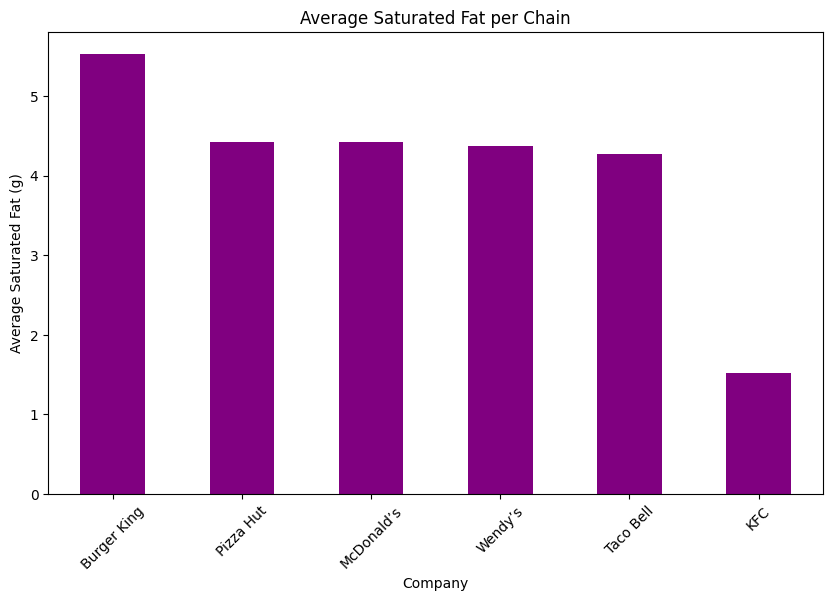

In [22]:
avg_satfat = df[companies].multiply(df['Saturated Fat (g)'], axis=0).sum() / df[companies].sum()
avg_satfat.index = avg_satfat.index.str.replace('Company_', '')

plt.figure(figsize=(10, 6))
avg_satfat.sort_values(ascending=False).plot(kind='bar', color='purple')
plt.title('Average Saturated Fat per Chain')
plt.xlabel('Company')
plt.ylabel('Average Saturated Fat (g)')
plt.xticks(rotation=45)
plt.show()

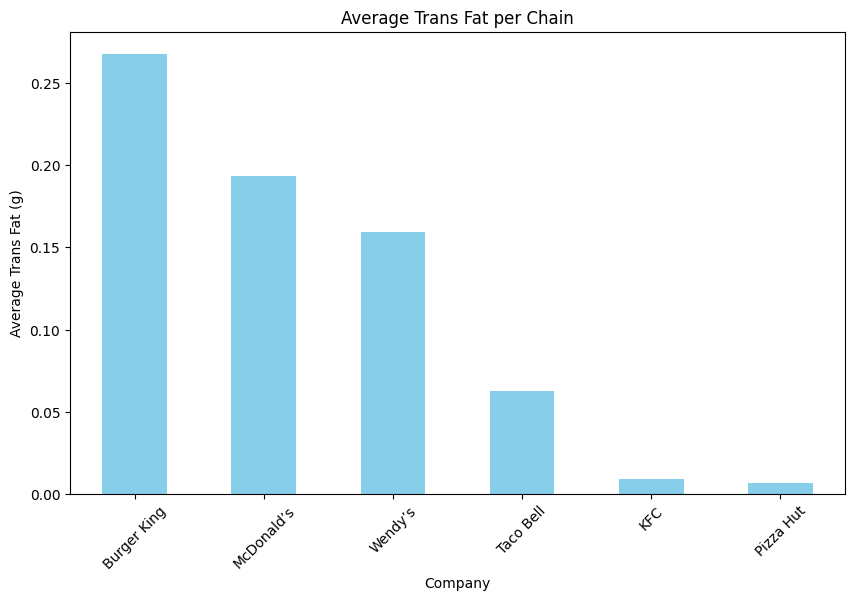

In [23]:
avg_transfat = df[companies].multiply(df['Trans Fat (g)'], axis=0).sum() / df[companies].sum()
avg_transfat.index = avg_transfat.index.str.replace('Company_', '')

plt.figure(figsize=(10, 6))
avg_transfat.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Average Trans Fat per Chain')
plt.xlabel('Company')
plt.ylabel('Average Trans Fat (g)')
plt.xticks(rotation=45)
plt.show()

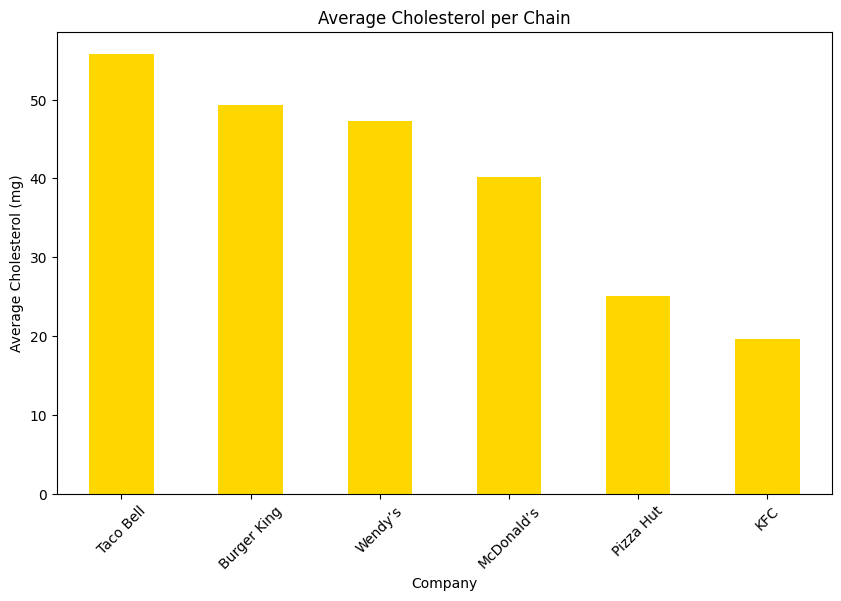

In [24]:
avg_cholesterol = df[companies].multiply(df['Cholesterol (mg)'], axis=0).sum() / df[companies].sum()
avg_cholesterol.index = avg_cholesterol.index.str.replace('Company_', '')

plt.figure(figsize=(10, 6))
avg_cholesterol.sort_values(ascending=False).plot(kind='bar', color='gold')
plt.title('Average Cholesterol per Chain')
plt.xlabel('Company')
plt.ylabel('Average Cholesterol (mg)')
plt.xticks(rotation=45)
plt.show()

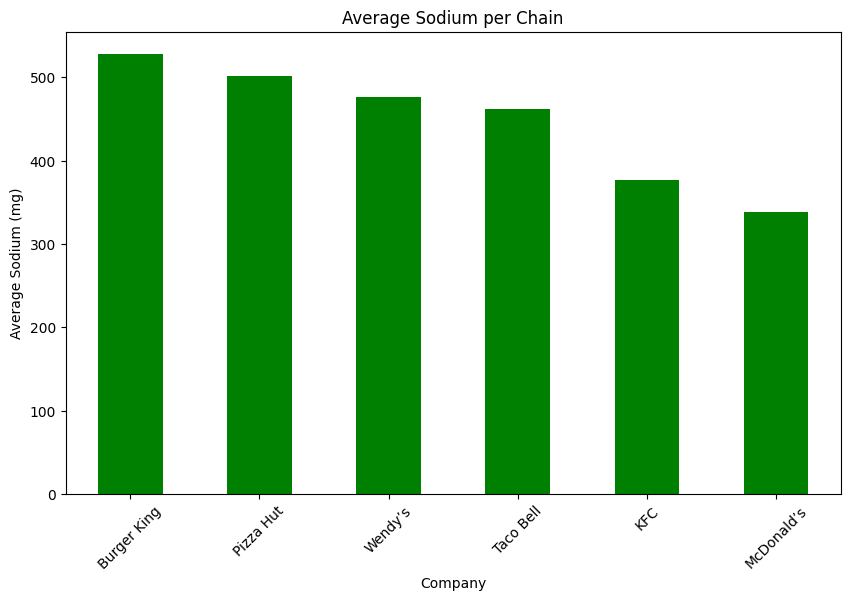

In [25]:
avg_sodium = df[companies].multiply(df['Sodium (mg)'], axis=0).sum() / df[companies].sum()
avg_sodium.index = avg_sodium.index.str.replace('Company_', '')

plt.figure(figsize=(10, 6))
avg_sodium.sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Average Sodium per Chain')
plt.xlabel('Company')
plt.ylabel('Average Sodium (mg)')
plt.xticks(rotation=45)
plt.show()

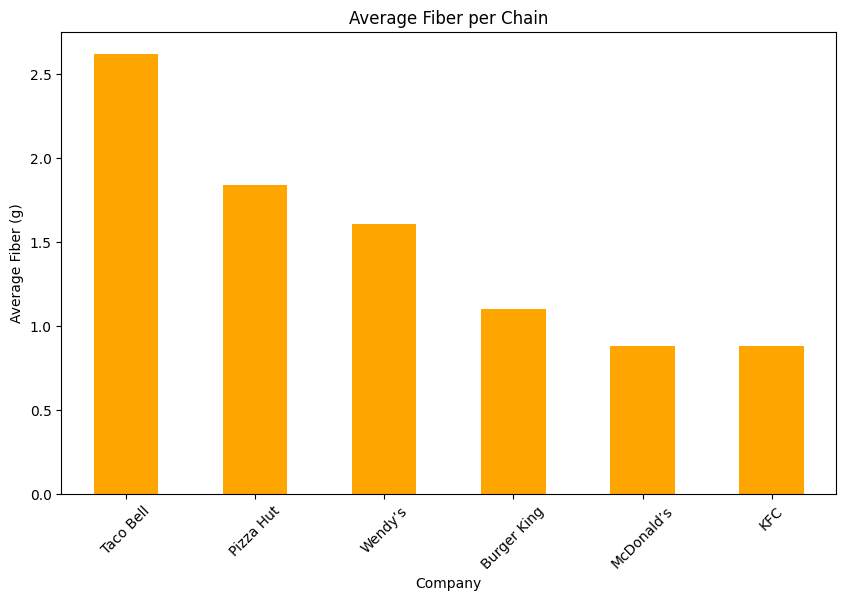

In [26]:
avg_fiber = df[companies].multiply(df['Fiber (g)'], axis=0).sum() / df[companies].sum()
avg_fiber.index = avg_fiber.index.str.replace('Company_', '')

plt.figure(figsize=(10, 6))
avg_fiber.sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Average Fiber per Chain')
plt.xlabel('Company')
plt.ylabel('Average Fiber (g)')
plt.xticks(rotation=45)
plt.show()

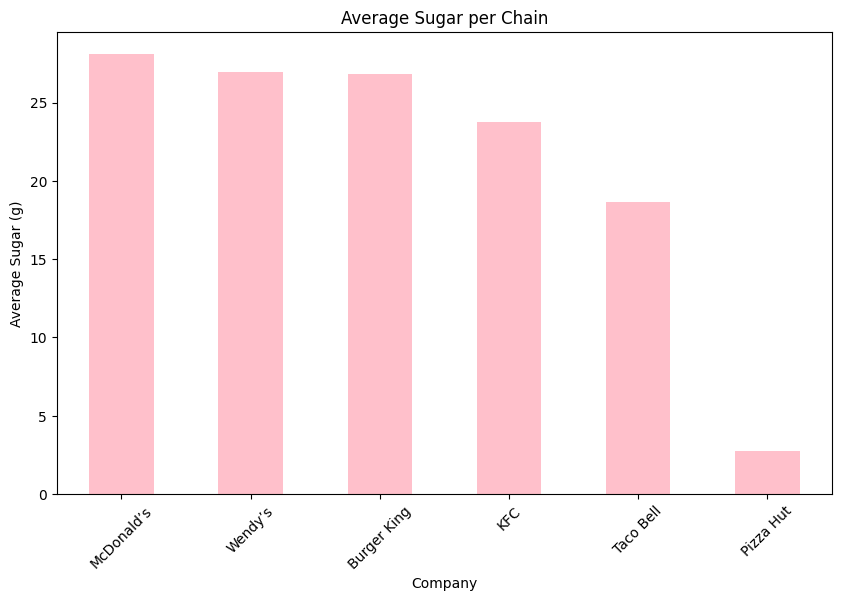

In [27]:
avg_sugar = df[companies].multiply(df['Sugar (g)'], axis=0).sum() / df[companies].sum()
avg_sugar.index = avg_sugar.index.str.replace('Company_', '')

plt.figure(figsize=(10, 6))
avg_sugar.sort_values(ascending=False).plot(kind='bar', color='pink')
plt.title('Average Sugar per Chain')
plt.xlabel('Company')
plt.ylabel('Average Sugar (g)')
plt.xticks(rotation=45)
plt.show()

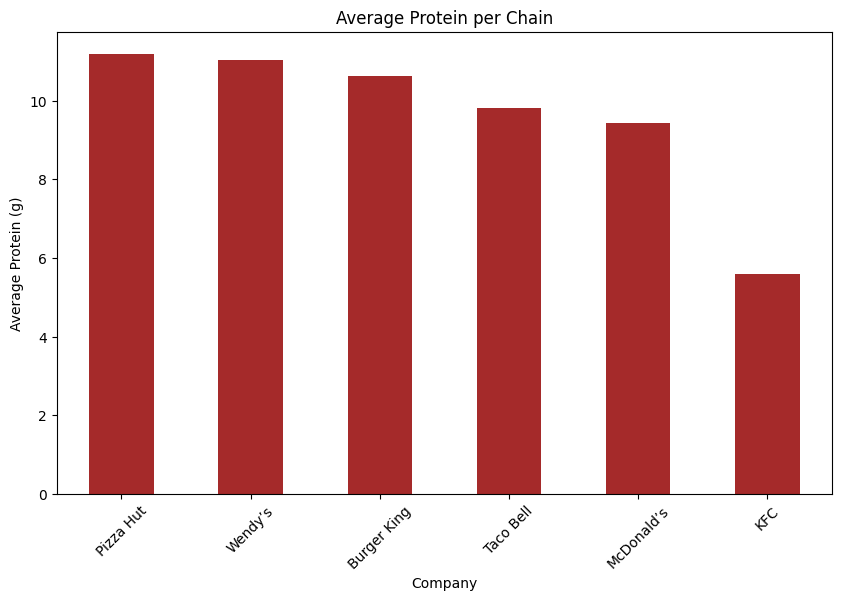

In [28]:
avg_protein = df[companies].multiply(df['Protein (g)'], axis=0).sum() / df[companies].sum()
avg_protein.index = avg_protein.index.str.replace('Company_', '')

plt.figure(figsize=(10, 6))
avg_protein.sort_values(ascending=False).plot(kind='bar', color='brown')
plt.title('Average Protein per Chain')
plt.xlabel('Company')
plt.ylabel('Average Protein (g)')
plt.xticks(rotation=45)
plt.show()

In [29]:
#AVERAGE WEIGHTED RANKING AMONG THE SEVEN FEATURES WE USED 
nutrients = ['Saturated Fat (g)', 'Trans Fat (g)', 'Cholesterol (mg)', 'Sodium (mg)', 'Fiber (g)', 'Sugar (g)', 'Protein (g)']

avg_nutrients = {}

for column in nutrients:
    #The average of each nutrient per company gets calculated again
    avg = df[companies].multiply(df[column], axis=0).sum() / df[companies].sum()
    avg.index = avg.index.str.replace('Company_', '')

    #The average/value gets paired with the key value
    avg_nutrients[column] = avg

#Turns the dictionary into a new DataFrame
avg_df = pd.DataFrame(avg_nutrients)

unhealthy = ['Saturated Fat (g)', 'Trans Fat (g)', 'Cholesterol (mg)', 'Sodium (mg)', 'Sugar (g)']
healthy = ['Fiber (g)', 'Protein (g)']

#New dataframe
score = pd.DataFrame()

for column in unhealthy:
    #The higher they rank in this, the more unhealthy they are
    score[column] = avg_df[column].rank(ascending=False)  
for column in healthy:
    #The lower they rank in this, the more unhealthy they are
    score[column] = avg_df[column].rank(ascending=True)  

# Composite/Weighted Score score
score['Weighted Ranking'] = score.sum(axis=1) / 7
print(score.sort_values('Weighted Ranking'))


             Saturated Fat (g)  Trans Fat (g)  Cholesterol (mg)  Sodium (mg)  \
Burger King                1.0            1.0               2.0          1.0   
McDonald’s                 3.0            2.0               4.0          6.0   
Wendy’s                    4.0            3.0               3.0          3.0   
KFC                        6.0            5.0               6.0          5.0   
Taco Bell                  5.0            4.0               1.0          4.0   
Pizza Hut                  2.0            6.0               5.0          2.0   

             Sugar (g)  Fiber (g)  Protein (g)  Weighted Ranking  
Burger King        3.0        3.0          4.0          2.142857  
McDonald’s         1.0        2.0          2.0          2.857143  
Wendy’s            2.0        4.0          5.0          3.428571  
KFC                4.0        1.0          1.0          4.000000  
Taco Bell          5.0        6.0          3.0          4.000000  
Pizza Hut          6.0        5.0    

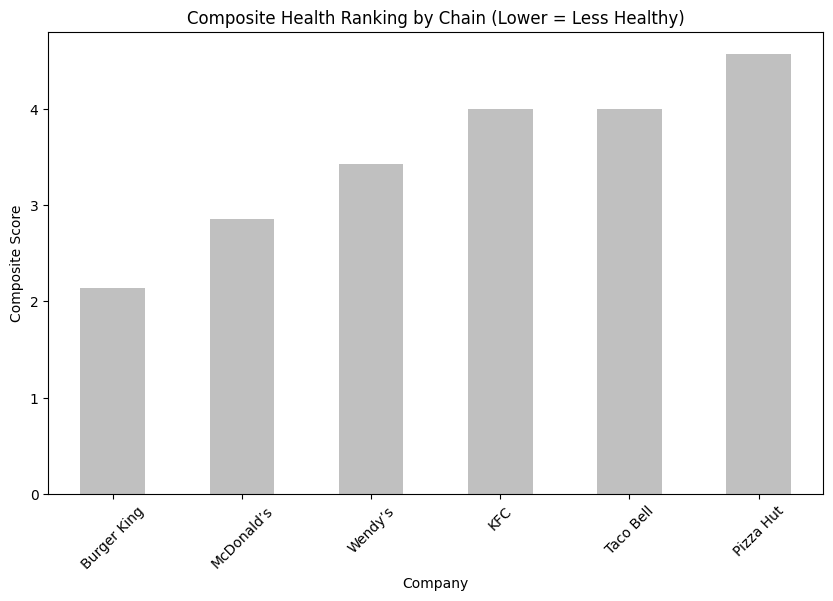

In [30]:
plt.figure(figsize=(10, 6))
score['Weighted Ranking'].sort_values().plot(kind='bar', color='silver')
plt.title('Composite Health Ranking by Chain (Lower = Less Healthy)')
plt.xlabel('Company')
plt.ylabel('Composite Score')
plt.xticks(rotation=45)
plt.show()

In [31]:
print([c for c in df.columns if 'Mc' in c])

['Company_McDonald’s']


In [32]:
#SIGNIFICANCE TESTING
from scipy import stats

#Formatting to make it look like a table (<25 = left-align 25 chars, >12 = right-align 12 chars, etc.)
print(f"{'Nutrient':<25} {'F-Statistic':>12} {'P-Value':>10} {'Significant?':>12}")
print("-" * 62)

for n in nutrients:
    groups = [df[df[c] == 1][n] for c in companies]
    f_stat, p_value = stats.f_oneway(*groups)
    significant = "Yes" if p_value < 0.05 else "No"
    print(f"{n:<25} {f_stat:>12.4f} {p_value:>10.4f} {significant:>12}")

Nutrient                   F-Statistic    P-Value Significant?
--------------------------------------------------------------
Saturated Fat (g)              16.7730     0.0000          Yes
Trans Fat (g)                   9.1421     0.0000          Yes
Cholesterol (mg)                7.9935     0.0000          Yes
Sodium (mg)                     4.9640     0.0002          Yes
Fiber (g)                      17.8035     0.0000          Yes
Sugar (g)                       9.4390     0.0000          Yes
Protein (g)                     7.2698     0.0000          Yes


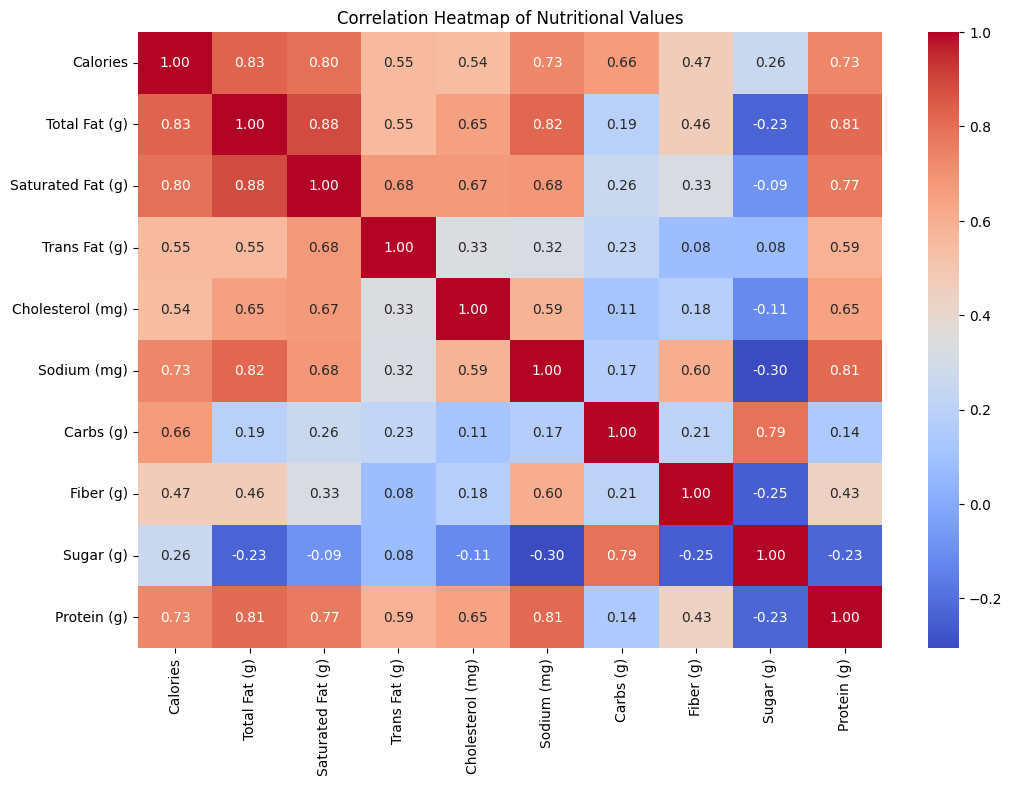

In [33]:
#CORRELATION HEATMAP
plt.figure(figsize=(12, 8))
sns.heatmap(df[['Calories', 'Total Fat (g)', 'Saturated Fat (g)', 'Trans Fat (g)', 
                'Cholesterol (mg)', 'Sodium (mg)', 'Carbs (g)', 'Fiber (g)', 
                'Sugar (g)', 'Protein (g)']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Nutritional Values')
plt.show()